In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import os
plot_dir = "/home/bbc8731/BioMedFormer/data/plot/disease_area"
data_dir_biomedformer = "/home/bbc8731/BioMedFormer/data/result/disease_area/"


In [2]:
# for some files we only had log file not LP_results, using this code we can obtain LP_results using log files

# file_name = "biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001"

# # List of log files
# log_dirs = [
#     "/home/bbc8731/BioMedFormer/data/log/disease_area/anemia/biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_seed42.log",
#     "/home/bbc8731/BioMedFormer/data/log/disease_area/anemia/biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_seed43.log",
#     "/home/bbc8731/BioMedFormer/data/log/disease_area/anemia/biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_seed44.log",
#     "/home/bbc8731/BioMedFormer/data/log/disease_area/anemia/biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_seed45.log",
#     "/home/bbc8731/BioMedFormer/data/log/disease_area/anemia/biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_seed46.log"
# ]

# dfs = []

# for log_file in log_dirs:
#     with open(log_file, "r") as f:
#         lines = f.readlines()

#     test_blocks = []
#     capture = False

#     for line in lines:
#         if line.strip().startswith("LP_result_test:"):
#             capture = True
#             current_block = []
#             continue

#         if capture:
#             if line.strip() == "" or line.strip().startswith(("Epoch", "hit_", "precision_", "LP_result_val:")):
#                 capture = False
#                 test_blocks.append(current_block)
#             else:
#                 current_block.append(line.strip())

#     if capture and current_block:
#         test_blocks.append(current_block)

#     if test_blocks:
#         last_block = test_blocks[-1]
#         columns = last_block[0].split()
#         values = [float(x) for x in last_block[1].split()]
#         df = pd.DataFrame([values], columns=columns)
#         df["seed"] = log_file.split("seed")[-1].split(".log")[0]  # extract seed
#         dfs.append(df)

# # Combine all DataFrames
# final_df = pd.concat(dfs, ignore_index=True)

# # Show or save
# print(final_df)
# final_df.to_csv(os.path.join(data_dir_biomedformer, file_name, "LP_test.csv"), index=False)


Mean AUPRC: 0.970000


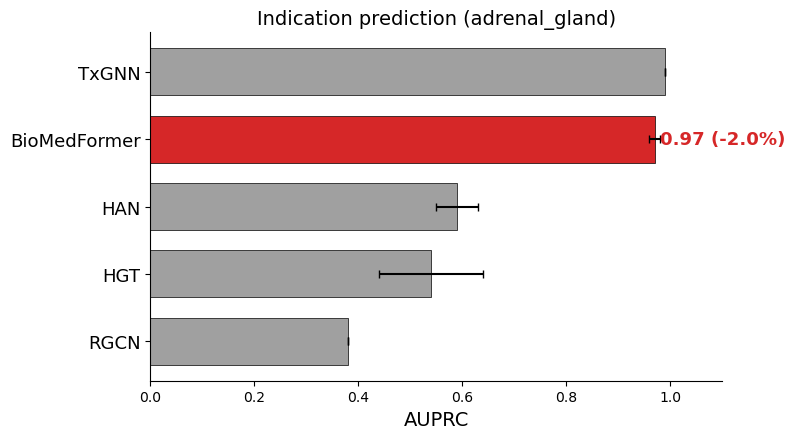

In [3]:
# AUPRC adrenal_gland
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_adrenal_gland_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250709_132239/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_adrenal_gland_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_033234/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']

# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)

print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.48, 0.50, 0.48, 0.50, 0.38, 0.59, 0.54, 0.64, 0.99, mean_indication_auprcs]
# stds = [0.05, 0.02, 0.02, 0.03, 0.00, 0.04, 0.10, 0.00, 0.00, std_indication_auprcs]

methods = ["RGCN", "HGT", "HAN", "TxGNN", "BioMedFormer"]
means_other = [0.38, 0.54, 0.59, 0.99]

means = [0.38, 0.54, 0.59, 0.99, mean_indication_auprcs]
stds = [0.00, 0.10, 0.04, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]
else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (adrenal_gland)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_adrenal_gland.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.840000


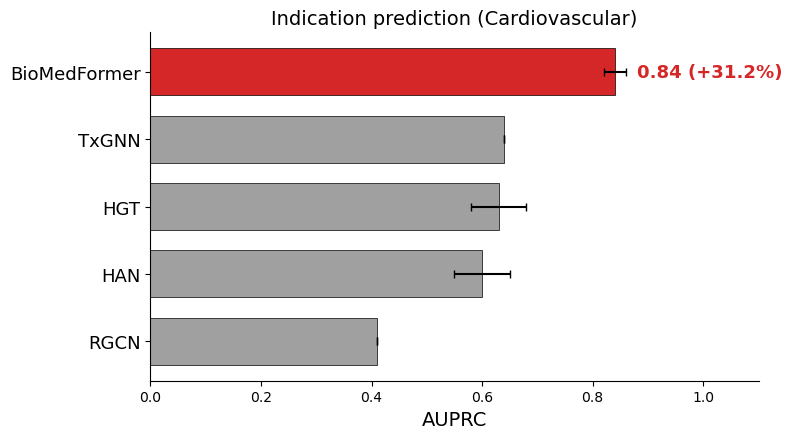

In [4]:
### Cardiovascular
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_cardiovascular_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250712_162025/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_cardiovascular_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_144220/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']

# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.49, 0.50, 0.50, 0.50, 0.41, 0.63, 0.60, 0.66, 0.64, 0.82]
# stds = [0.01, 0.02, 0.00, 0.02, 0.00, 0.05, 0.05, 0.00, 0.00, 0.00]

methods = ["RGCN", "HAN", "HGT", "TxGNN", "BioMedFormer"]

means_other = [0.41, 0.60, 0.63, 0.64]

means = [0.41, 0.60, 0.63, 0.64, mean_indication_auprcs]
stds = [0.00, 0.05, 0.05, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]



# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Cardiovascular)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Cardiovascular.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.960000


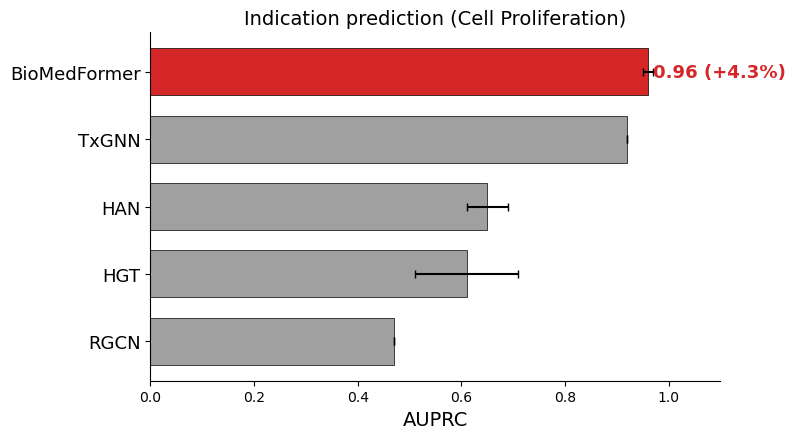

In [5]:
##### Cell Proliferation
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_cell_proliferation_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250713_194245/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_cell_proliferation_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_103221/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.51, 0.50, 0.47, 0.51, 0.47, 0.65, 0.61, 0.83, 0.92, 0.95]
# stds = [0.01, 0.01, 0.00, 0.00, 0.00, 0.04, 0.10, 0.00, 0.00, 0.00]


methods = ["RGCN", "HGT", "HAN", "TxGNN", "BioMedFormer"]
means_other = [0.47, 0.61, 0.65, 0.92]
means = [0.47, 0.61, 0.65, 0.92, mean_indication_auprcs]
stds = [0.00, 0.10, 0.04, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]



# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Cell Proliferation)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Cell_Proliferation.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.590000


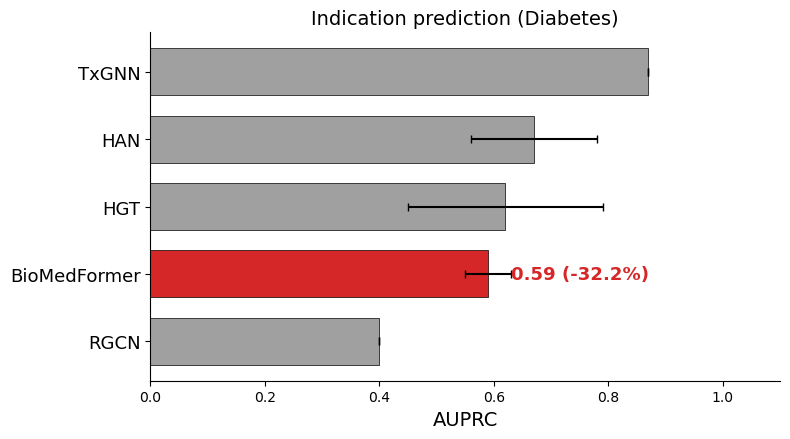

In [6]:
### Diabetes
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_diabetes_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250714_171502/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_diabetes_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250807_104629/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.50, 0.52, 0.47, 0.52, 0.40, 0.67, 0.62, 0.69, 0.87, 0.48]
# stds = [0.03, 0.03, 0.01, 0.01, 0.00, 0.11, 0.17, 0.00, 0.00, 0.00]


means_other = [0.40, 0.62, 0.67, 0.87]
methods = ["RGCN", "HGT", "HAN", "TxGNN", "BioMedFormer"]
means = [0.40, 0.62, 0.67, 0.87, mean_indication_auprcs]
stds = [0.00, 0.17, 0.11, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Diabetes)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Diabetes.png"), dpi=300, bbox_inches="tight")
plt.show()

Mean AUPRC: 0.920000


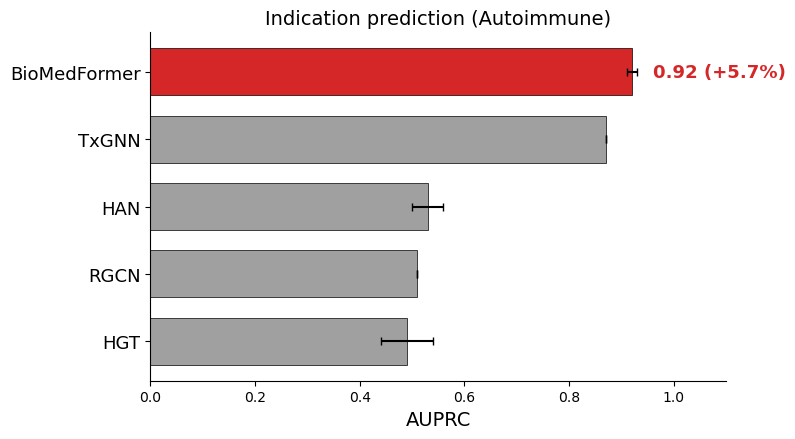

In [7]:
### Autoimmune
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_autoimmune_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250710_075924/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_autoimmune_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_171225/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.51, 0.49, 0.56, 0.52, 0.51, 0.53, 0.49, 0.66, 0.87, 0.92]
# stds = [0.03, 0.01, 0.01, 0.04, 0.00, 0.03, 0.05, 0.00, 0.00, 0.00]

methods = ["HGT", "RGCN", "HAN", "TxGNN", "BioMedFormer"]
means_other = [0.49, 0.51, 0.53, 0.87]
means = [0.49, 0.51, 0.53, 0.87, mean_indication_auprcs]
stds = [0.05, 0.00, 0.03, 0.00, std_indication_auprcs]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Autoimmune)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Autoimmune.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.980000


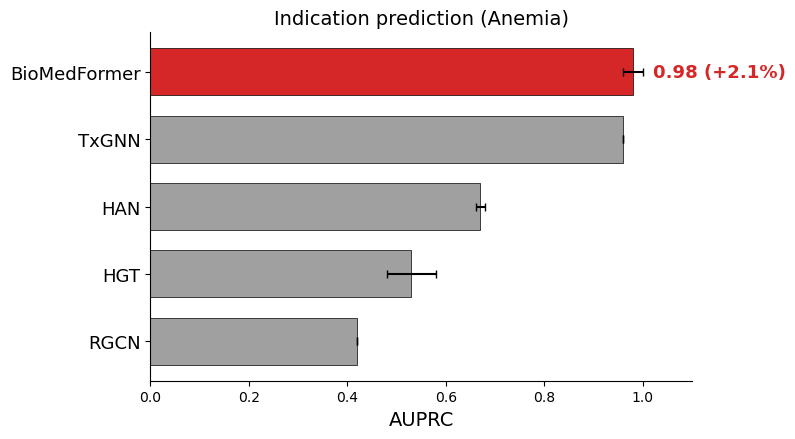

In [8]:
### Anemia
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_anemia_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_anemia_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250803_103939/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.47, 0.53, 0.49, 0.51, 0.42, 0.67, 0.53, 0.64, 0.96, 0.98]
# stds = [0.02, 0.02, 0.02, 0.03, 0.00, 0.01, 0.05, 0.00, 0.00, 0.00]

means_other = [0.42, 0.53, 0.67, 0.96]

methods = ["RGCN", "HGT", "HAN", "TxGNN", "BioMedFormer"]
means = [0.42, 0.53, 0.67, 0.96, mean_indication_auprcs]
stds = [0.00, 0.05, 0.01, 0.00, std_indication_auprcs]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Anemia)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Anemia.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.900000


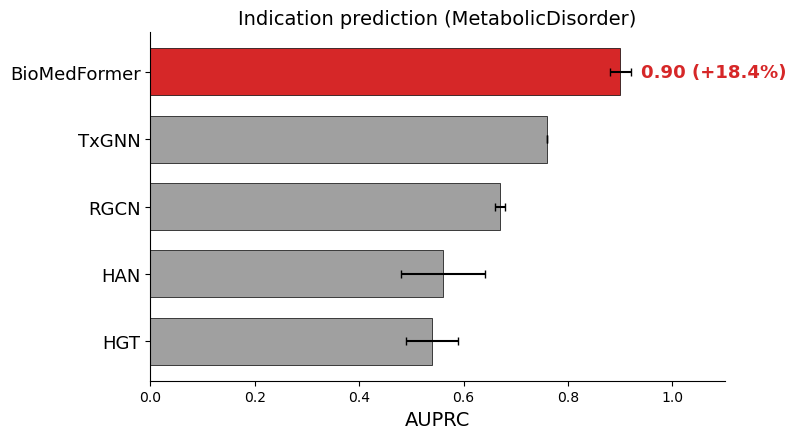

In [11]:
# ### MetabolicDisorder
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_metabolic_disorder_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250717_175847/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_metabolic_disorder_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_173629/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.51, 0.54, 0.41, 0.51, 0.67, 0.56, 0.54, 0.68, 0.76, 0.88]
# stds = [0.01, 0.06, 0.00, 0.04, 0.01, 0.08, 0.05, 0.00, 0.00, 0.00]

means_other = [0.54, 0.56, 0.67, 0.76]
methods = ["HGT", "HAN", "RGCN", "TxGNN", "BioMedFormer"]
means = [0.54, 0.56, 0.67, 0.76, mean_indication_auprcs]
stds = [0.05, 0.08, 0.01, 0.00, std_indication_auprcs]

# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (MetabolicDisorder)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_MetabolicDisorder.png"), dpi=300, bbox_inches="tight")
plt.show()


Mean AUPRC: 0.860000


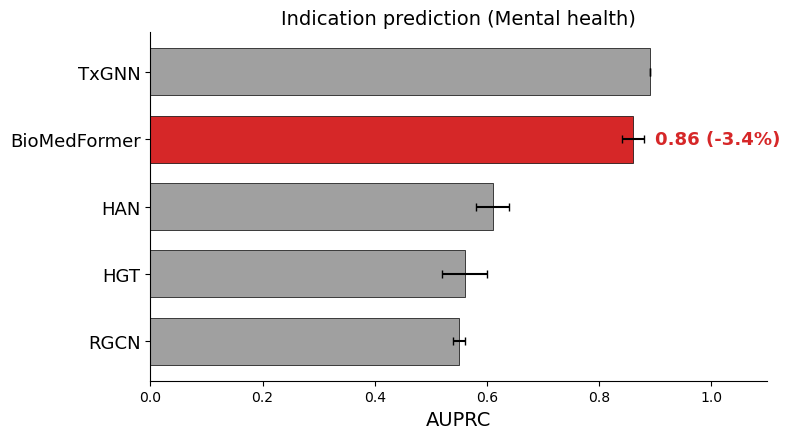

In [9]:
### Mental health
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_mental_health_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250716_210048/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_mental_health_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_065041/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")

#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.50, 0.50, 0.44, 0.50, 0.55, 0.61, 0.56, 0.64, 0.89, mean_indication_auprcs]
# stds = [0.02, 0.02, 0.00, 0.01, 0.01, 0.03, 0.04, 0.00, 0.00, std_indication_auprcs]

means_other = [0.55, 0.56, 0.61, 0.89]
methods = ["RGCN", "HGT", "HAN", "TxGNN", "BioMedFormer"]
means = [0.55, 0.56, 0.61, 0.89, mean_indication_auprcs]
stds = [0.01, 0.04, 0.03, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Mental health)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Mental_health.png"), dpi=300, bbox_inches="tight")
plt.show()

Mean AUPRC: 0.970000


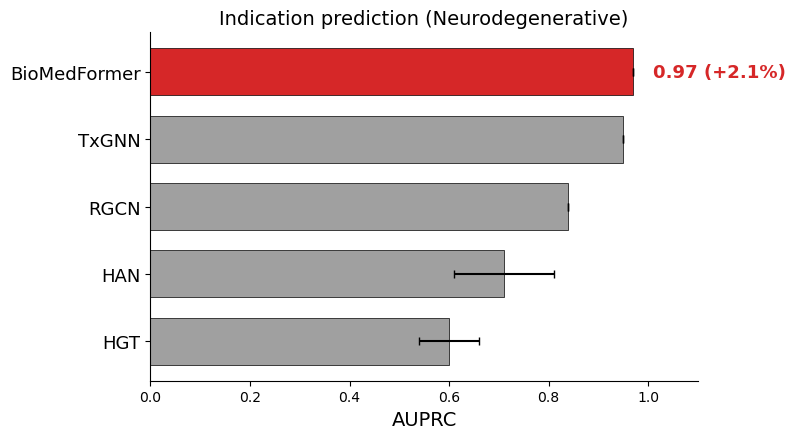

In [13]:
# ### Neurodegenerative
# Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_neurodigenerative_indication_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250718_124725/LP_test.csv"))
Lp_test = pd.read_csv(os.path.join(data_dir_biomedformer, "biomedformer_atr_v2_neurodigenerative_['indication', 'contraindication']_inductive_wl5_wpn30_dim300_head5_lencoder30_bs4000_lr0.0001_20250811_231544/LP_test.csv"))
Lp_test = Lp_test.iloc[::2]

indication_auprcs = Lp_test['auprc']
# Compute their means
mean_indication_auprcs = round(indication_auprcs.mean(), 2)
std_indication_auprcs = round(indication_auprcs.std(), 2)
print(f"Mean AUPRC: {mean_indication_auprcs:.6f}")
#########################
# methods = ["KL", "JS", "Proximity", "DSD", "RGCN", "HAN", "HGT", "BioBERT", "TxGNN", "BioMedFormer"]
# means = [0.50, 0.51, 0.49, 0.51, 0.84, 0.71, 0.60, 0.57, 0.95, 0.95]
# stds = [0.03, 0.03, 0.01, 0.02, 0.00, 0.10, 0.06, 0.00, 0.00, 0.00]

means_other = [0.60, 0.71, 0.84, 0.95]
methods = ["HGT", "HAN", "RGCN", "TxGNN", "BioMedFormer"]
means = [0.60, 0.71, 0.84, 0.95, mean_indication_auprcs]
stds = [0.06, 0.10, 0.00, 0.00, std_indication_auprcs]


# Sort by performance
data = sorted(zip(means, stds, methods), reverse=True)
means, stds, methods = zip(*data)

# Compute % improvement over best baseline (excluding BioMedFormer)
baseline_max = max(means_other)
if (mean_indication_auprcs-baseline_max)>0:
    improvement = round((mean_indication_auprcs - baseline_max) / baseline_max * 100, 1)
    colors = ['#D62728' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

else:
    improvement = round((baseline_max- mean_indication_auprcs) / baseline_max * 100, 1)
    colors = ['#1F77B4' if method == "BioMedFormer" else '#A0A0A0' for method in methods]

# Colors: BioMedFormer = red, others = grey

# Plot
# Define a consistent per-bar vertical space
bar_height = 0.7
vertical_padding = 1.0  # For title/labels

# Dynamically scale figure height based on number of bars
fig_height = len(methods) * bar_height + vertical_padding

fig, ax = plt.subplots(figsize=(8, fig_height))


y_pos = np.arange(len(methods))

bars = ax.barh(y_pos, means, xerr=stds, color=colors,
               capsize=3, edgecolor='black', linewidth=0.5, height=0.7)

# Reference line for best baseline
# ax.axvline(x=baseline_max, color='gray', linestyle='--', linewidth=1)
# ax.text(baseline_max + 0.01, -0.7, f"Best baseline ({baseline_max:.2f})", fontsize=12, color='gray')

# Annotate BioMedFormer
for i, (bar, method, val) in enumerate(zip(bars, methods, means)):
    if method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)>0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (+{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')

    elif method == "BioMedFormer" and (mean_indication_auprcs-baseline_max)<0:
        ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} (-{improvement}%)", va='center', fontsize=13, fontweight='bold', color='#D62728')


# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel("AUPRC", fontsize=14)
ax.set_title("Indication prediction (Neurodegenerative)", fontsize=14)

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

# Save
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "biomedformer_indication_Neurodegenerative.png"), dpi=300, bbox_inches="tight")
plt.show()
